# Cài đặt các thư viện cần thiết

In [1]:
# Cell 1
!pip install -q transformers datasets evaluate
!pip install -q accelerate -U
!pip install -q pyvi scikit-learn scikit-multilearn
!pip uninstall -y torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


# Import thư viện & Mount Google Drive

In [2]:
import pandas as pd
import numpy as np
import torch
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset

# Nếu file của bạn lưu trên Drive thì uncomment 2 dòng bên dưới
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Config - Cấu hình toàn bộ siêu tham số

In [3]:
class Config:
    # --- ĐƯỜNG DẪN ---
    # Thay bằng đường dẫn file CSV thực tế của bạn
    CSV_FILE_PATH = "/content/data.csv"

    # --- MÔ HÌNH ---
    MODEL_NAME = "vinai/phobert-base-v2" # Dùng bản v2 tối ưu hơn
    MAX_LENGTH = 256  # Độ dài tối đa của văn bản (PhoBERT hỗ trợ tối đa 256 token từ subword)

    # --- THAM SỐ HUẤN LUYỆN ---
    BATCH_SIZE = 16   # Nếu bị out-of-memory GPU, hãy giảm xuống 8
    EPOCHS = 8        # Với 1700 mẫu, chạy khoảng 4-8 epochs là tối ưu
    LEARNING_RATE = 2e-5
    TEST_SIZE = 0.15  # Dành 15% dữ liệu cho tập Validation
    RANDOM_SEED = 42

    # --- ĐỊNH NGHĨA LABEL ---
    LABEL_COLS = [
        "ANTI_GOVERNMENT_REGIME",
        "INCITE_VIOLENCE_SOCIAL_DISORDER",
        "OFFICIAL_NEWS_CURRENT_EVENTS",
        "GENERAL_CONTENT"
    ]
    NUM_LABELS = len(LABEL_COLS)

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


# Tiền xử lý dữ liệu

In [4]:
# Cell 4
# Đọc dữ liệu
df = pd.read_csv(Config.CSV_FILE_PATH)

# Xóa các dòng có văn bản bị null (nếu có)
df = df.dropna(subset=['text'])

# Hàm tiền xử lý: Phân từ (Word Segmentation) bằng Pyvi
# Ví dụ: "Cán bộ đi lùng" -> "Cán_bộ đi lùng"
def preprocess_text(text):
    text = str(text).strip()
    return ViTokenizer.tokenize(text)

df['text_clean'] = df['text'].apply(preprocess_text)

# Chuyển các cột nhãn thành 1 cột chứa list các giá trị (kiểu float để dùng BCE Loss)
df['labels'] = df[Config.LABEL_COLS].values.astype(float).tolist()

print(f"Tổng số lượng dữ liệu sau tiền xử lý: {len(df)}")
display(df[['text_clean', 'labels']].head(3))

Tổng số lượng dữ liệu sau tiền xử lý: 3887


,text_clean,labels
0,"NGHỀ MỚI “ HỐT BẠC ” , CÁN_BỘ ĐI LÙNG BẮT CHIM...","[0.0, 1.0, 0.0, 0.0]"
1,Bôi_trơn là chủ_trương của đảng !,"[1.0, 0.0, 0.0, 0.0]"
2,Có 30 CSGT ở TP. HCM bị 2 cha con_quay video n...,"[0.0, 1.0, 0.0, 0.0]"


# Chia tập dữ liệu và Tokenization

In [5]:
# 1. Chia train/validation với iterative_train_test_split để cân bằng nhãn
# Chuẩn bị dữ liệu đầu vào dưới dạng Numpy Array
X = np.array(df['text_clean'].tolist()).reshape(-1, 1)
Y = np.array(df['labels'].tolist())

# Đã SỬA: Bỏ random_state vì thư viện không hỗ trợ tham số này
X_train, y_train, X_val, y_val = iterative_train_test_split(
    X, Y, test_size=Config.TEST_SIZE
)

# Chuyển lại về DataFrame cho dễ xử lý tiếp
train_df = pd.DataFrame({'text_clean': X_train.flatten(), 'labels': y_train.tolist()})
val_df = pd.DataFrame({'text_clean': X_val.flatten(), 'labels': y_val.tolist()})

# 2. Tạo đối tượng HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['text_clean', 'labels']])
val_dataset = Dataset.from_pandas(val_df[['text_clean', 'labels']])

# 3. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)

def tokenize_function(examples):
    # Tokenize văn bản thô
    outputs = tokenizer(
        examples["text_clean"],
        padding="max_length",
        truncation=True,
        max_length=Config.MAX_LENGTH
    )
    # Đã SỬA: Ép kiểu toàn bộ label sang float (0.0 và 1.0) để né lỗi Tensor Type khi tính BCE Loss
    outputs["labels"] = [list(map(float, label)) for label in examples["labels"]]
    return outputs

# 4. Áp dụng Tokenization
# Bổ sung: remove_columns để loại bỏ text thô sau khi tokenize, giải phóng RAM và tránh lỗi định dạng String
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text_clean"])
tokenized_val = val_dataset.map(tokenize_function, batched=True, remove_columns=["text_clean"])

# 5. Format sang Tensor của PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"Số mẫu Train: {len(tokenized_train)} | Số mẫu Val: {len(tokenized_val)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Map:   0%|          | 0/3303 [00:00<?, ? examples/s]

Map:   0%|          | 0/584 [00:00<?, ? examples/s]

Số mẫu Train: 3303 | Số mẫu Val: 584


# Định nghĩa Mô hình và Hàm Đánh giá

In [6]:
# Cell 6
from sklearn.metrics import f1_score, accuracy_score

# Khởi tạo Mô hình: Lưu ý sử dụng problem_type cho multi-label
model = AutoModelForSequenceClassification.from_pretrained(
    Config.MODEL_NAME,
    num_labels=Config.NUM_LABELS,
    problem_type="multi_label_classification"
).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Do là Multi-label, dùng Sigmoid để đưa dự đoán về [0, 1] cho mỗi nhãn
    probs = 1 / (1 + np.exp(-logits))

    # Ngưỡng (Threshold) = 0.5. Nếu xác suất > 0.5 thì tính là có nhãn đó (1), ngược lại là (0)
    predictions = (probs >= 0.5).astype(int)

    # Tính Macro F1 score (Rất quan trọng nếu các nhãn bị mất cân bằng)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, predictions)

    return {
        'f1_macro': f1_macro,
        'accuracy': accuracy
    }

print("Đã khởi tạo Model và Hàm Metrics thành công!")

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Đã khởi tạo Model và Hàm Metrics thành công!


# Cấu hình Trainer & Bắt đầu Huấn Luyện

In [7]:
# Cell 7
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/phobert_checkpoints",
    eval_strategy="epoch",      # Đánh giá validation sau mỗi epoch
    save_strategy="epoch",      # Lưu mô hình sau mỗi epoch
    learning_rate=Config.LEARNING_RATE,
    per_device_train_batch_size=Config.BATCH_SIZE,
    per_device_eval_batch_size=Config.BATCH_SIZE,
    # num_train_epochs=8,
    num_train_epochs=Config.EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,# Tự động tải mô hình tốt nhất ở bước cuối
    metric_for_best_model="f1_macro", # Lựa chọn model có f1_macro cao nhất
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=10,
    max_grad_norm = 1.0
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

# Chạy lệnh huấn luyện
print("Bắt đầu quá trình huấn luyện...")
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Bắt đầu quá trình huấn luyện...


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.244251,0.223297,0.872391,0.791096
2,0.168037,0.156871,0.911139,0.830479
3,0.125266,0.155066,0.910221,0.832192
4,0.058112,0.136441,0.911383,0.839041
5,0.052308,0.142772,0.915026,0.845890
6,0.042463,0.158213,0.904570,0.830479
7,0.032387,0.151214,0.916940,0.845890
8,0.027097,0.151145,0.915390,0.844178


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1656, training_loss=0.11265682705322613, metrics={'train_runtime': 1305.0551, 'train_samples_per_second': 20.247, 'train_steps_per_second': 1.269, 'total_flos': 3476285686628352.0, 'train_loss': 0.11265682705322613, 'epoch': 8.0})

## Sơ đồ hóa kết quả huấn luyện

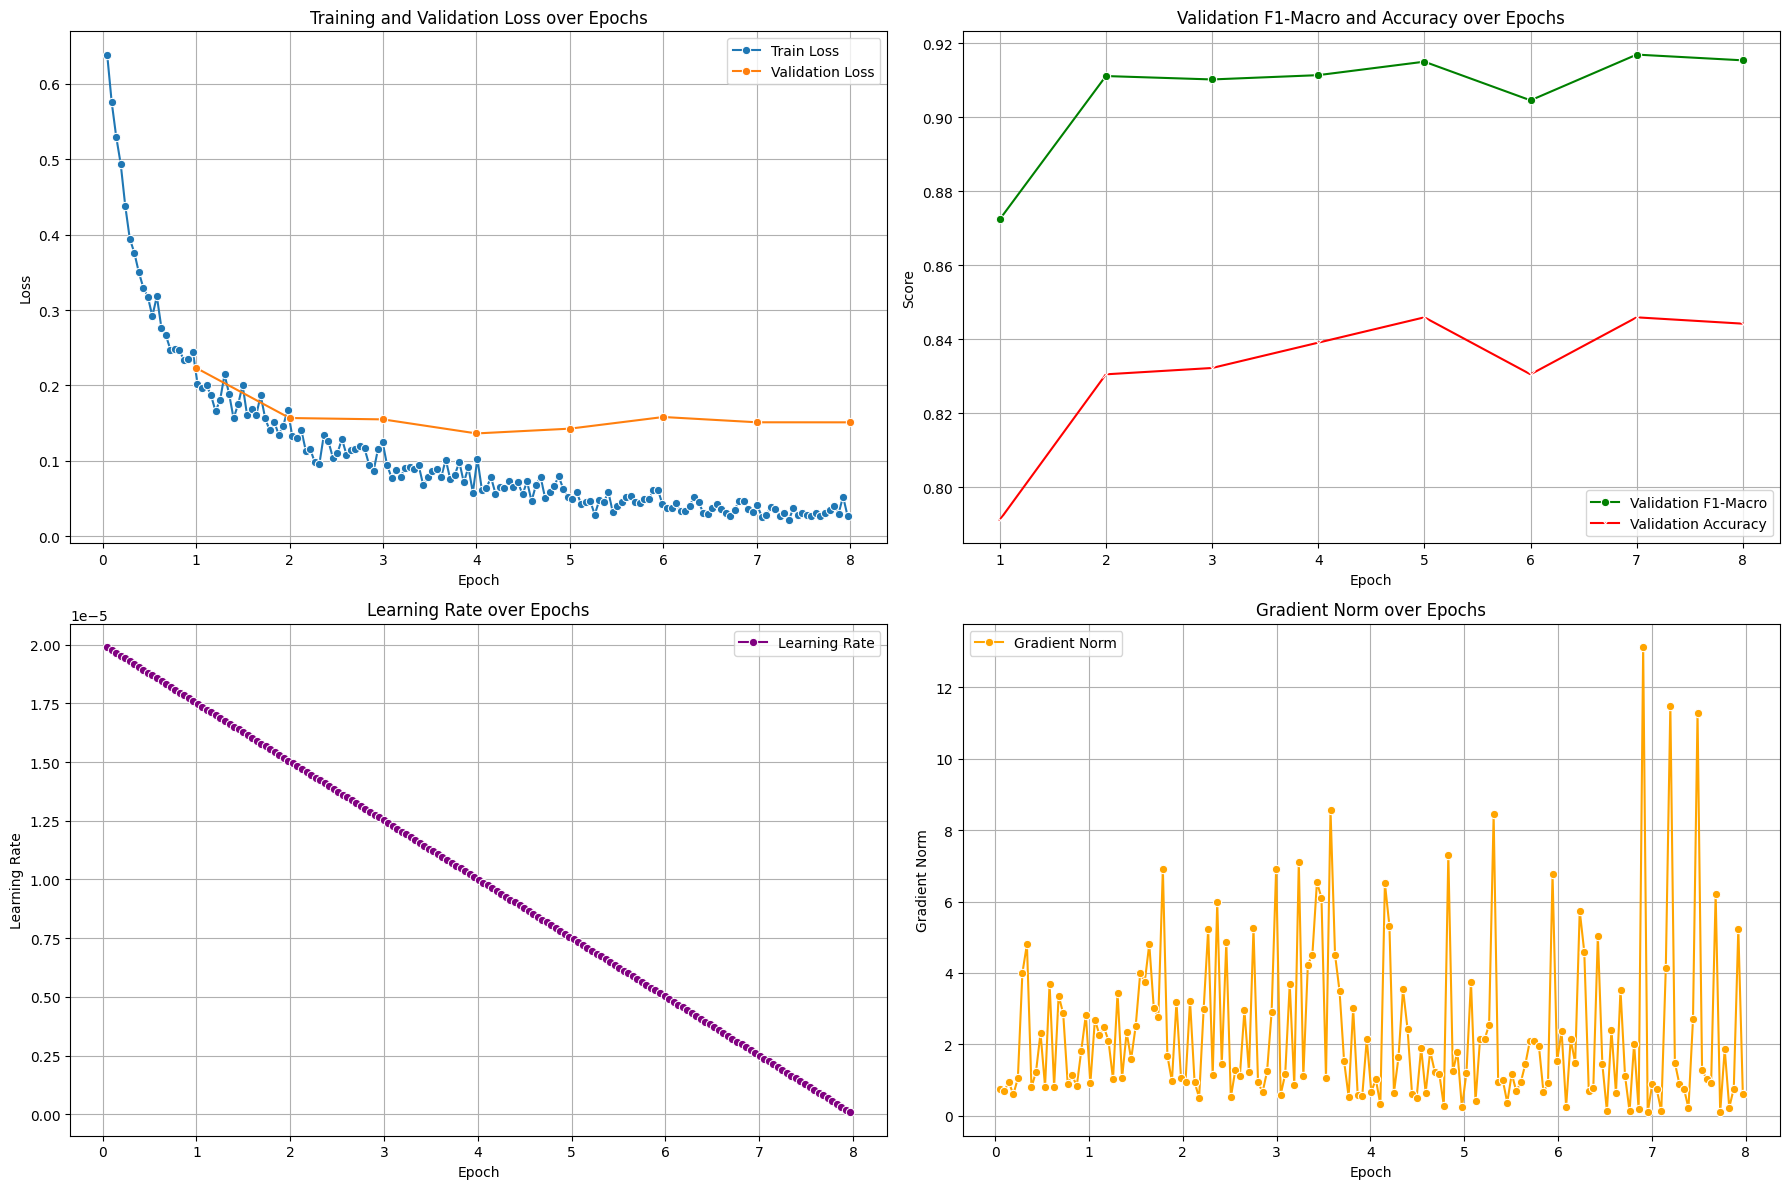

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lấy lịch sử huấn luyện từ trainer
logs = trainer.state.log_history

# Chuyển đổi thành DataFrame để dễ xử lý
logs_df = pd.DataFrame(logs)

# Lọc ra các log của từng epoch
# Train logs: chứa loss, learning_rate, grad_norm
train_logs = logs_df[logs_df['loss'].notna()]
# Validation logs: chứa eval_loss, eval_f1_macro, eval_accuracy
val_logs = logs_df[logs_df['eval_loss'].notna()]

# Tạo figure với 2x2 grid để hiển thị nhiều biểu đồ hơn
plt.figure(figsize=(18, 12))

# Biểu đồ 1: Training and Validation Loss
plt.subplot(2, 2, 1)
sns.lineplot(x=train_logs['epoch'], y=train_logs['loss'], label='Train Loss', marker='o')
sns.lineplot(x=val_logs['epoch'], y=val_logs['eval_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ 2: Validation F1-Macro and Accuracy
plt.subplot(2, 2, 2)
sns.lineplot(x=val_logs['epoch'], y=val_logs['eval_f1_macro'], label='Validation F1-Macro', marker='o', color='green')
sns.lineplot(x=val_logs['epoch'], y=val_logs['eval_accuracy'], label='Validation Accuracy', marker='x', color='red')
plt.title('Validation F1-Macro and Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

# Biểu đồ 3: Learning Rate over Epochs
plt.subplot(2, 2, 3)
sns.lineplot(x=train_logs['epoch'], y=train_logs['learning_rate'], label='Learning Rate', marker='o', color='purple')
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.legend()

# Biểu đồ 4: Gradient Norm over Epochs (useful for debugging stability)
plt.subplot(2, 2, 4)
sns.lineplot(x=train_logs['epoch'], y=train_logs['grad_norm'], label='Gradient Norm', marker='o', color='orange')
plt.title('Gradient Norm over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Gradient Norm')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Lưu Mô hình và Dự đoán Thử

In [9]:
# Cell 8
# 1. Lưu mô hình xuống thư mục
model_save_path = "/content/drive/MyDrive/phobert-reactionary-classifier"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Đã lưu mô hình tại: {model_save_path}\n")

# 2. Dự đoán thử một nội dung
test_text = "Hàng loạt cán bộ nhận hối lộ hàng chục tỷ đồng. Chế độ này đã mục nát từ bên trong, người dân phải chịu khổ mãi sao."

# Phân từ text test
clean_test = ViTokenizer.tokenize(test_text)

# Tokenize
inputs = tokenizer(clean_test, return_tensors="pt", truncation=True, max_length=Config.MAX_LENGTH).to(device)

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    # Áp dụng Sigmoid để lấy xác suất của từng label
    probs = torch.sigmoid(logits).cpu().numpy()[0]
    preds = (probs >= 0.5).astype(int)

print("=== KẾT QUẢ DỰ ĐOÁN ===")
print(f"Văn bản: {test_text}\n")
for label, prob, pred in zip(Config.LABEL_COLS, probs, preds):
    trang_thai = 'CÓ vi phạm' if pred == 1 else 'KHÔNG'
    print(f"- [{trang_thai}] {label} (Xác suất: {prob*100:.1f}%)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu mô hình tại: /content/drive/MyDrive/phobert-reactionary-classifier

=== KẾT QUẢ DỰ ĐOÁN ===
Văn bản: Hàng loạt cán bộ nhận hối lộ hàng chục tỷ đồng. Chế độ này đã mục nát từ bên trong, người dân phải chịu khổ mãi sao.

- [KHÔNG] ANTI_GOVERNMENT_REGIME (Xác suất: 1.7%)
- [CÓ vi phạm] INCITE_VIOLENCE_SOCIAL_DISORDER (Xác suất: 95.8%)
- [KHÔNG] OFFICIAL_NEWS_CURRENT_EVENTS (Xác suất: 1.6%)
- [KHÔNG] GENERAL_CONTENT (Xác suất: 1.3%)


## 🔍 Phương pháp: Khoanh vùng và Đánh bẫy mẫu lỗi (Confident Learning)

Chúng ta sẽ sử dụng mô hình vừa huấn luyện xong để dự đoán lại toàn bộ tập dữ liệu. Những mẫu có **Loss cao nhất** hoặc có sự **mâu thuẫn lớn nhất** giữa nhãn thực tế và dự đoán của mô hình thường là những mẫu bị gán nhãn sai hoặc gây nhiễu.

In [10]:
import torch.nn.functional as F
from tqdm.auto import tqdm

# 1. Chuẩn bị hàm tính Loss cho từng mẫu đơn lẻ
def identify_label_errors(model, tokenizer, df, label_cols, device, threshold=0.5):
    model.eval()
    results = []

    print("Đang chạy dự đoán trên toàn bộ dữ liệu để tìm lỗi...")

    for i, row in tqdm(df.iterrows(), total=len(df)):
        text = row['text_clean']
        actual_labels = torch.tensor(row['labels']).unsqueeze(0).to(device)

        # Tokenize
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=Config.MAX_LENGTH).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.sigmoid(logits)

            # Tính Binary Cross Entropy loss cho từng mẫu
            loss = F.binary_cross_entropy_with_logits(logits, actual_labels, reduction='none').mean().item()

        # Lưu kết quả
        res = {
            'index_goc': i,
            'text': row['text'],
            'actual_labels': row['labels'],
            'pred_probs': probs.cpu().numpy()[0].tolist(),
            'loss': loss
        }
        results.append(res)

    return pd.DataFrame(results)

# Thực hiện quét dữ liệu
error_df = identify_label_errors(model, tokenizer, df, Config.LABEL_COLS, device)

Đang chạy dự đoán trên toàn bộ dữ liệu để tìm lỗi...


  0%|          | 0/3887 [00:00<?, ?it/s]

### Lọc ra các mẫu nghi ngờ lỗi nhất

Chúng ta sẽ sắp xếp các mẫu theo `loss` giảm dần. Những mẫu có `loss` cao nhất là những mẫu mà mô hình "ngạc nhiên" nhất khi thấy nhãn bạn đặt.

In [11]:
# Sắp xếp theo loss để tìm các mẫu gây nhiễu nhất
suspicious_samples = error_df.sort_values(by='loss', ascending=False)

def format_label_string(labels):
    return " | ".join([f"{Config.LABEL_COLS[i]}: {labels[i]}" for i in range(len(labels))])

# Hiển thị Top 20 mẫu có khả năng sai nhãn cao nhất
print("TOP 20 MẪU CÓ KHẢ NĂNG SAI NHÃN CAO NHẤT (LOSS CAO NHẤT)")
for i, row in suspicious_samples.head(20).iterrows():
    print(f"\n[Hạng {i}] - Loss: {row['loss']:.4f}")
    print(f"Nội dung: {row['text'][:200]}...")
    print(f"Nhãn của bạn:  {row['actual_labels']}")
    print(f"Model dự đoán: {[round(p, 3) for p in row['pred_probs']]}")
    print("-" * 50)

TOP 20 MẪU CÓ KHẢ NĂNG SAI NHÃN CAO NHẤT (LOSS CAO NHẤT)

[Hạng 437] - Loss: 2.2471
Nội dung: Thủ tướng Lê Minh Hưng: Không khuyến khích dân giữ vàng vì không tạo ra giá trị gia tăng kinh tế. À chuẩn bị phát hành CHỨNG CHỈ VÀNG nữa là đủ combo. Lấy mấy tờ giấy đổi vàng thật, cấp cho cái bằng y...
Nhãn của bạn:  [1.0, 1.0, 0.0, 0.0]
Model dự đoán: [0.003, 0.06, 0.364, 0.005]
--------------------------------------------------

[Hạng 3117] - Loss: 2.2111
Nội dung: ĐANG VIRAL ĐOẠN VIDEO CẬU SINH VIÊN CHIẾU LỊCH SỬ CHATGPT MÀ MÌNH DÙNG ĐỂ "HỖ TRỢ KỲ THI" LÊN CAMERA LỄ TỐT NGHIỆP ⁉️...
Nhãn của bạn:  [0.0, 0.0, 0.0, 1.0]
Model dự đoán: [0.009, 0.008, 0.987, 0.011]
--------------------------------------------------

[Hạng 3027] - Loss: 2.1887
Nội dung: Cambridge xác nhận lộ đề thi Toán quốc tế ở nhiều nước, trong đó có Việt Nam: Hủy kết quả, toàn bộ thí sinh phải thi lại...
Nhãn của bạn:  [0.0, 0.0, 0.0, 1.0]
Model dự đoán: [0.008, 0.008, 0.985, 0.011]
----------------------------------------

### Xuất file lỗi ra CSV để sửa tay

Bạn có thể tải file này về, mở bằng Excel để kiểm tra và sửa lại nhãn ở cột `actual_labels`.

In [12]:
# Lưu top 100 mẫu nghi ngờ nhất ra file CSV để bạn kiểm tra
suspicious_samples.head(200).to_csv("/content/check_label_errors.csv", index=False, encoding='utf-8-sig')
print("Đã xuất file check_label_errors.csv. Hãy tải về trong thư mục file bên trái để kiểm tra!")

Đã xuất file check_label_errors.csv. Hãy tải về trong thư mục file bên trái để kiểm tra!
